# Monte Carlo Sampling Methods

## Learning Objectives

- Understand why we need methods to generate random samples from arbitrary distributions.
- Implement the **inverse transform method** from scratch and prove why it works.
- Implement **acceptance-rejection sampling** and understand its efficiency trade-offs.
- Apply **importance sampling** for estimating expectations under difficult distributions.
- Connect these methods to the MCMC techniques used in Bayesian inference (Module 07).

## Prerequisites

- Module 02.01–02.03 (discrete and continuous distributions, CDFs)
- Basic calculus (integration, change of variables)

In [1]:
import sys, os, shutil
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    os.system(
        "sudo apt-get update -qq && sudo apt-get install -y -qq "
        "libcairo2-dev libpango1.0-dev && pip install -q manim ipython==8.21.0"
    )

_miktex_bin = Path.home() / "AppData/Local/Programs/MiKTeX/miktex/bin/x64"
if _miktex_bin.exists() and str(_miktex_bin) not in os.environ.get("PATH", ""):
    os.environ["PATH"] += os.pathsep + str(_miktex_bin)

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

sys.path.insert(0, os.path.abspath("../../src"))
from amstats.plotting import apply_style

apply_style()

rng = np.random.default_rng(42)


class Cfg:
    root = Path("../../").resolve()
    gif_dir = root / "media" / "gifs"
    has_latex: bool = (
        shutil.which("latex") is not None or shutil.which("pdflatex") is not None
    )

    def __init__(self):
        self.gif_dir.mkdir(parents=True, exist_ok=True)
        if not self.has_latex:
            print("⚠ LaTeX not found — MathTex will fall back to Text().")

    def apply_manim_config(self):
        from manim import config as mcfg

        mcfg.format = "gif"

    def math_text(self, expr, **kwargs):
        from manim import MathTex, Text

        if self.has_latex:
            return MathTex(expr, **kwargs)
        return Text(expr, **kwargs)

    def save_gifs(self, clean=True):
        local_media = Path("media")
        found = list(local_media.rglob("*.gif")) if local_media.exists() else []
        if not found:
            print("  No new GIFs to save.")
            return
        for gif in found:
            dest = self.gif_dir / gif.name
            shutil.copy2(gif, dest)
            print(f"  ✓ media/gifs/{gif.name}")
        if clean:
            for sub in ("videos", "images", "Tex"):
                d = local_media / sub
                if d.exists():
                    shutil.rmtree(d, ignore_errors=True)
            print("  Cleaned up local temp render files.")


cfg = Cfg()

In [2]:
from manim import *

cfg.apply_manim_config()
math_text = cfg.math_text

from amstats.manim_utils import C, COLORS

---

## 1. Why Monte Carlo Sampling?

In the previous notebooks we studied probability distributions — their PMFs, PDFs, CDFs, means, and variances. We can *describe* these distributions analytically. But in practice we often need to **generate random samples** from a distribution, and this turns out to be a surprisingly deep problem.

**Why do we need samples?**

1. **Estimating expectations.** If $X \sim f$, then $E[g(X)] = \int g(x) f(x)\, dx$. For many choices of $g$ and $f$, this integral has no closed-form solution. But if we can draw samples $X_1, \ldots, X_n \sim f$, then by the Law of Large Numbers:

$$\hat{\mu}_n = \frac{1}{n} \sum_{i=1}^n g(X_i) \xrightarrow{\text{a.s.}} E[g(X)] \quad \text{as } n \to \infty$$

2. **Simulation.** Monte Carlo simulation lets us study complex systems (queuing networks, financial models, physical processes) by repeatedly sampling random inputs and observing the outputs.

3. **Bayesian inference.** In Module 07 we will need to draw samples from posterior distributions that have no analytical form. The MCMC methods we'll use there are sophisticated extensions of the basic sampling techniques we develop in this notebook.

**The core problem:** Your computer can generate $U \sim \text{Uniform}(0, 1)$ — that's built into every programming language. But how do you turn these uniform random numbers into samples from an *arbitrary* distribution $f$?

This notebook presents three fundamental answers:

| Method                   | Idea                                             | When to use                             |
|--------------------------|--------------------------------------------------|-----------------------------------------|
| **Inverse transform**    | Map uniform samples through $F^{-1}$             | CDF inverse available in closed form    |
| **Acceptance-rejection** | Propose from an easy distribution, accept/reject | Any bounded density, no $F^{-1}$ needed |
| **Importance sampling**  | Sample from a different distribution, reweight   | Estimating expectations, rare events    |

---

## 2. The Inverse Transform Method

### 2.1 The key theorem

The inverse transform method is the most elegant connection between uniform random variables and arbitrary distributions. The idea is beautifully simple: if you can invert the CDF, you can sample from the distribution.

**Theorem (Inverse Transform).** Let $F$ be a continuous, strictly increasing CDF. If $U \sim \text{Uniform}(0, 1)$, then

$$X = F^{-1}(U) \sim F$$

That is, $X$ has CDF $F$.

**Proof.** We need to show that $P(X \leq x) = F(x)$ for all $x$.

$$P(X \leq x) = P\big(F^{-1}(U) \leq x\big)$$

Since $F$ is strictly increasing, $F^{-1}(U) \leq x$ if and only if $U \leq F(x)$. Therefore:

$$P\big(F^{-1}(U) \leq x\big) = P\big(U \leq F(x)\big)$$

Since $U \sim \text{Uniform}(0, 1)$ and $F(x) \in [0, 1]$, we have $P(U \leq F(x)) = F(x)$. Hence:

$$P(X \leq x) = F(x) \quad \blacksquare$$

The proof works because a uniform random variable has the remarkable property that $P(U \leq u) = u$ for any $u \in [0, 1]$. This makes the CDF "transparent" — it passes right through.

### 2.2 Geometric intuition

Think of it this way: the CDF $F(x)$ maps values on the $x$-axis to probabilities on the $y$-axis (between 0 and 1). The inverse $F^{-1}$ reverses this — it maps probabilities back to values. So if you feed in a *uniformly distributed* probability $U$, you get back a value $X$ whose distribution matches $F$.

Regions where $F$ is steep (high density) correspond to many uniform values being mapped to a narrow range of $x$ — exactly producing more samples where the density is high.

### 2.3 From scratch: Exponential distribution

Let's apply the inverse transform to the **Exponential($\lambda$)** distribution.

**Step 1 — CDF:**

$$F(x) = 1 - e^{-\lambda x}, \quad x \geq 0$$

**Step 2 — Invert:** Set $u = F(x) = 1 - e^{-\lambda x}$ and solve for $x$:

$$u = 1 - e^{-\lambda x} \implies e^{-\lambda x} = 1 - u \implies -\lambda x = \ln(1 - u) \implies x = -\frac{\ln(1 - u)}{\lambda}$$

**Step 3 — Since $U$ and $1 - U$ have the same distribution** (both Uniform(0,1)), we can simplify:

$$X = -\frac{\ln U}{\lambda}$$

This is our sampling formula. Let's implement it and verify it produces the correct distribution.

In [6]:
# From scratch: inverse transform sampling for Exponential(λ)
def sample_exponential(lam, n, rng):
    """Generate n samples from Exponential(λ) using inverse transform."""
    u = rng.uniform(size=n)
    return -np.log(u) / lam


lam = 2.0
n_samples = 50_000
samples = sample_exponential(lam, n_samples, rng)

# Verify: compare sample statistics to theory
print(f"Exponential(λ={lam}):")
print(f"  Theory:  E[X] = {1 / lam:.4f},   Var(X) = {1 / lam**2:.4f}")
print(f"  Sample:  mean = {samples.mean():.4f},   var  = {samples.var():.4f}")

Exponential(λ=2.0):
  Theory:  E[X] = 0.5000,   Var(X) = 0.2500
  Sample:  mean = 0.4996,   var  = 0.2529


The sample statistics match the theoretical values closely. Now let's compare the histogram to the true PDF visually.

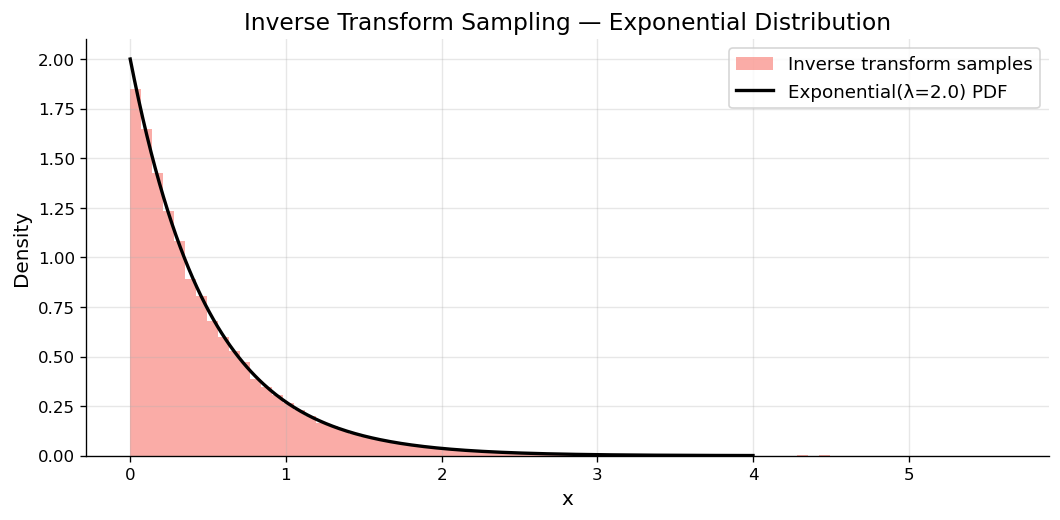

In [7]:
# Histogram vs theoretical PDF
fig, ax = plt.subplots(figsize=(9, 4.5))

x = np.linspace(0, 4, 300)
ax.hist(samples, bins=80, density=True, alpha=0.6, label="Inverse transform samples")
ax.plot(
    x, stats.expon(scale=1 / lam).pdf(x), "k-", lw=2, label=f"Exponential(λ={lam}) PDF"
)

ax.set_xlabel("x")
ax.set_ylabel("Density")
ax.set_title("Inverse Transform Sampling — Exponential Distribution")
ax.legend()
plt.tight_layout()
plt.show()

### 2.4 Visualising the inverse transform

The following animation shows the inverse transform in action. Uniform samples on the $y$-axis (left) are mapped through the inverse CDF curve to produce Exponential samples on the $x$-axis (bottom). Watch how the density of points on the $x$-axis is highest near zero — exactly where the Exponential PDF is largest.

Manim Community v0.18.1

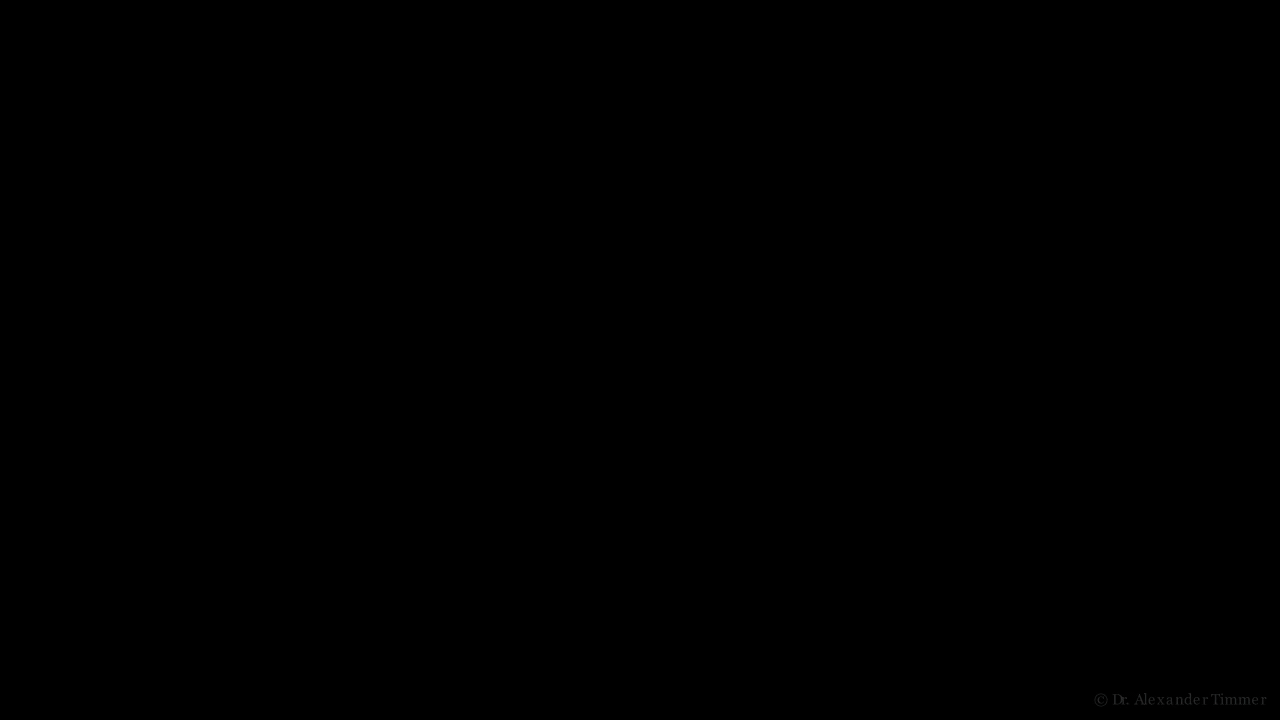

In [ ]:
%%manim -qm -v WARNING InverseTransformDemo


class InverseTransformDemo(Scene):
    """Animate uniform samples being mapped through the inverse CDF
    to produce exponential samples."""

    def construct(self):
        # Watermark — add first so it's present the entire animation
        watermark = Text(
            "© Dr. Alexander Timmer", font_size=12, color=GREY, fill_opacity=0.3
        )
        watermark.to_corner(DR, buff=0.15)
        self.add(watermark)

        lam = 1.5
        title = Text("Inverse Transform: U → F⁻¹(U) → X", font_size=28).to_edge(UP)
        self.play(Write(title), run_time=0.6)

        # Axes: x-axis = sample value, y-axis = uniform [0,1]
        axes = Axes(
            x_range=[0, 4, 1],
            y_range=[0, 1, 0.2],
            x_length=8,
            y_length=5,
            axis_config={"include_numbers": True, "font_size": 16},
        ).shift(DOWN * 0.3)
        x_lbl = axes.get_x_axis_label(
            Text("x (Exponential samples)", font_size=16), edge=DOWN, direction=DOWN
        )
        y_lbl = axes.get_y_axis_label(
            Text("u (Uniform)", font_size=16), edge=LEFT, direction=LEFT
        )
        self.play(Create(axes), Write(x_lbl), Write(y_lbl), run_time=0.8)

        # Draw the CDF curve: F(x) = 1 - exp(-λx)
        cdf_curve = axes.plot(
            lambda x: 1 - np.exp(-lam * x), x_range=[0, 4], color=C.GOLD, stroke_width=3
        )
        cdf_label = Text("CDF: F(x)", font_size=16, color=C.GOLD).next_to(
            axes.c2p(3, 0.95), LEFT
        )
        self.play(Create(cdf_curve), Write(cdf_label), run_time=0.8)

        # Animate 15 samples flowing through the CDF
        np.random.seed(42)
        u_vals = np.random.uniform(0.02, 0.98, 15)

        for i, u in enumerate(u_vals[:15]):
            x_val = -np.log(1 - u) / lam  # inverse CDF

            # Dot on y-axis
            y_dot = Dot(axes.c2p(0, u), color=C.CYAN, radius=0.06)
            # Horizontal line to CDF
            h_line = DashedLine(
                axes.c2p(0, u), axes.c2p(x_val, u), color=C.CYAN, stroke_width=1.5
            )
            # Vertical line down to x-axis
            v_line = DashedLine(
                axes.c2p(x_val, u), axes.c2p(x_val, 0), color=C.SALMON, stroke_width=1.5
            )
            # Dot on x-axis
            x_dot = Dot(axes.c2p(x_val, 0), color=C.SALMON, radius=0.06)

            speed = 0.25 if i < 5 else 0.12
            self.play(FadeIn(y_dot), run_time=speed)
            self.play(Create(h_line), run_time=speed)
            self.play(Create(v_line), FadeIn(x_dot), run_time=speed)
            self.play(
                FadeOut(h_line), FadeOut(v_line), FadeOut(y_dot), run_time=speed * 0.5
            )

        self.wait(1)

### 2.5 From scratch: Triangular distribution

To reinforce the method, let's apply it to a less standard distribution. The **Triangular distribution** on $[0, 2]$ with peak at 1 has PDF:

$$f(x) = \begin{cases} x & 0 \leq x \leq 1 \\ 2 - x & 1 < x \leq 2 \end{cases}$$

**Step 1 — CDF (by integration):**

$$F(x) = \begin{cases} \frac{x^2}{2} & 0 \leq x \leq 1 \\ 1 - \frac{(2-x)^2}{2} & 1 < x \leq 2 \end{cases}$$

**Step 2 — Invert each piece:**

- For $0 \leq u \leq 0.5$: $u = x^2/2 \implies x = \sqrt{2u}$
- For $0.5 < u \leq 1$: $u = 1 - (2-x)^2/2 \implies x = 2 - \sqrt{2(1-u)}$

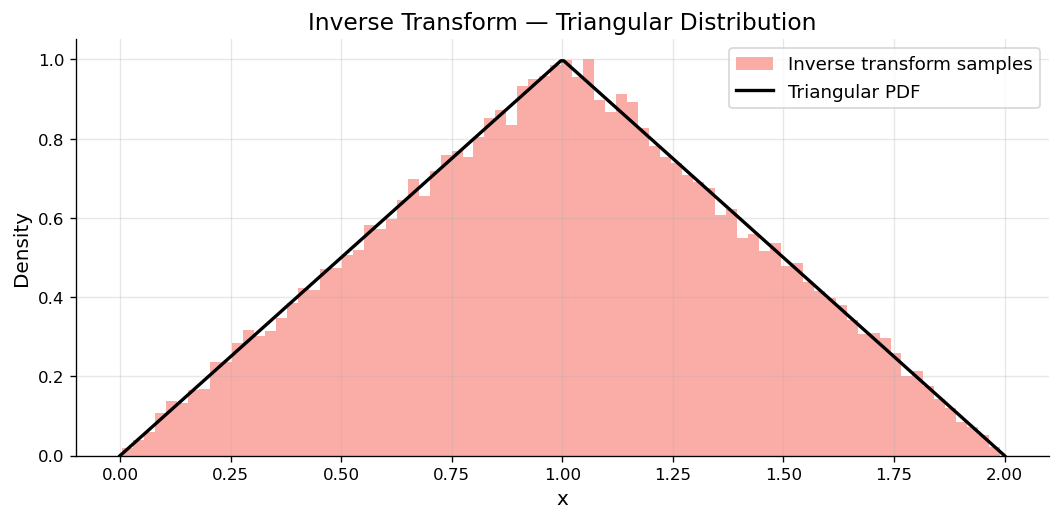

Theory:  E[X] = 1.0,   Var(X) = 0.1667
Sample:  mean = 1.0005,   var = 0.1667


In [8]:
# From scratch: inverse transform for Triangular(0, 1, 2)
def sample_triangular(n, rng):
    """Sample from Triangular(0, peak=1, 2) using inverse transform."""
    u = rng.uniform(size=n)
    x = np.where(u <= 0.5, np.sqrt(2 * u), 2 - np.sqrt(2 * (1 - u)))
    return x


tri_samples = sample_triangular(50_000, rng)

fig, ax = plt.subplots(figsize=(9, 4.5))
x = np.linspace(0, 2, 300)
pdf_tri = np.where(x <= 1, x, 2 - x)

ax.hist(
    tri_samples, bins=80, density=True, alpha=0.6, label="Inverse transform samples"
)
ax.plot(x, pdf_tri, "k-", lw=2, label="Triangular PDF")
ax.set_xlabel("x")
ax.set_ylabel("Density")
ax.set_title("Inverse Transform — Triangular Distribution")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Theory:  E[X] = 1.0,   Var(X) = {1 / 6:.4f}")
print(f"Sample:  mean = {tri_samples.mean():.4f},   var = {tri_samples.var():.4f}")

### 2.6 Professional tools

In practice, you rarely implement the inverse transform yourself. SciPy and NumPy provide optimised samplers for all standard distributions:

In [9]:
# Professional: scipy and numpy use optimised methods internally
from scipy.stats import expon, triang

# SciPy Exponential
scipy_samples = expon(scale=1 / lam).rvs(size=50_000, random_state=42)
print(f"SciPy Exponential: mean = {scipy_samples.mean():.4f}")

# NumPy Exponential (uses Ziggurat algorithm — faster than inverse transform!)
numpy_samples = rng.exponential(scale=1 / lam, size=50_000)
print(f"NumPy Exponential: mean = {numpy_samples.mean():.4f}")

# SciPy Triangular: triang(c, loc, scale) where c = (peak - loc) / scale
scipy_tri = triang(c=0.5, loc=0, scale=2).rvs(size=50_000, random_state=42)
print(f"SciPy Triangular:  mean = {scipy_tri.mean():.4f}")

SciPy Exponential: mean = 0.4981
NumPy Exponential: mean = 0.5002
SciPy Triangular:  mean = 0.9985


### 2.7 Limitations

The inverse transform is mathematically elegant but has a practical limitation: **you need $F^{-1}$ in closed form.** For many important distributions — the Normal, the Beta, the Gamma — the CDF involves special functions (error function, incomplete Beta, etc.) whose inverses are not available as simple formulae.

What do we do then? We need a method that works with the **PDF** directly, without requiring the CDF inverse. This is exactly what acceptance-rejection sampling provides.

---

## 3. Acceptance-Rejection Sampling

### 3.1 The algorithm

Suppose we want to sample from a **target** distribution with PDF $f(x)$, but we cannot compute $F^{-1}$. The acceptance-rejection method works as follows:

1. Choose a **proposal** distribution with PDF $g(x)$ that is easy to sample from.
2. Find a constant $M \geq 1$ such that $f(x) \leq M \cdot g(x)$ for all $x$. The function $M \cdot g(x)$ is called the **envelope**.
3. Repeat:
   - Draw $Y \sim g$ (a proposal)
   - Draw $U \sim \text{Uniform}(0, 1)$ (independently)
   - If $U \leq \dfrac{f(Y)}{M \cdot g(Y)}$, **accept** $Y$; otherwise **reject** and try again.

**Claim:** The accepted values are i.i.d. samples from $f$.

### 3.2 Why does it work?

**Proof.** We need to show that $P(Y \leq x \mid \text{accept}) = F(x)$.

The probability of accepting a proposal $Y = y$ is:

$$P(\text{accept} \mid Y = y) = P\left(U \leq \frac{f(y)}{M \cdot g(y)}\right) = \frac{f(y)}{M \cdot g(y)}$$

The overall acceptance probability is:

$$P(\text{accept}) = \int_{-\infty}^{\infty} \frac{f(y)}{M \cdot g(y)} \cdot g(y)\, dy = \frac{1}{M} \int f(y)\, dy = \frac{1}{M}$$

By Bayes' theorem, the density of accepted values is:

$$f_{Y \mid \text{accept}}(y) = \frac{P(\text{accept} \mid Y = y) \cdot g(y)}{P(\text{accept})} = \frac{\frac{f(y)}{M \cdot g(y)} \cdot g(y)}{\frac{1}{M}} = f(y) \quad \blacksquare$$

### 3.3 Efficiency

The acceptance probability is $1/M$. This means:
- On average, we need $M$ proposals to get one accepted sample.
- **We want $M$ as small as possible** — the tighter the envelope $M \cdot g(x)$ fits around $f(x)$, the more efficient the sampler.
- A bad choice of $g$ (e.g., a very wide Uniform) wastes most proposals.

### 3.4 From scratch: sampling from Beta(2.7, 6.3)

The Beta distribution's CDF involves the incomplete Beta function — no closed-form inverse. This makes it a perfect test case for acceptance-rejection.

**Target:** $f(x) = \text{Beta}(2.7, 6.3)$ on $[0, 1]$.

**Proposal 1 — Uniform(0, 1):** The simplest choice. We need $M = \max_x f(x)$, which is the mode height of the Beta PDF.

In [10]:
# From scratch: acceptance-rejection for Beta(2.7, 6.3) with Uniform proposal
a, b = 2.7, 6.3
target = stats.beta(a, b)

# M = max of the Beta PDF (at the mode)
mode = (a - 1) / (a + b - 2)
M_uniform = target.pdf(mode)  # envelope height
print(f"Beta({a},{b}) mode at x = {mode:.4f}, M = {M_uniform:.4f}")
print(f"Acceptance rate = 1/M = {1 / M_uniform:.4f} = {100 / M_uniform:.1f}%")


def accept_reject_beta_uniform(n_target, a, b, rng):
    """Sample n_target values from Beta(a,b) using Uniform proposal."""
    target = stats.beta(a, b)
    M = target.pdf((a - 1) / (a + b - 2))  # max of PDF

    samples = []
    n_proposed = 0
    while len(samples) < n_target:
        y = rng.uniform()  # proposal from g = Uniform(0,1)
        u = rng.uniform()  # acceptance threshold
        n_proposed += 1
        if u <= target.pdf(y) / M:  # accept?
            samples.append(y)

    return np.array(samples), n_proposed


samples_ar, n_proposed = accept_reject_beta_uniform(20_000, a, b, rng)
print(f"\nGenerated {len(samples_ar)} samples from {n_proposed} proposals")
print(f"Empirical acceptance rate: {len(samples_ar) / n_proposed:.4f}")
print(
    f"Theory:  E[X] = {a / (a + b):.4f},  Var(X) = {a * b / ((a + b) ** 2 * (a + b + 1)):.4f}"
)
print(f"Sample:  mean = {samples_ar.mean():.4f},  var  = {samples_ar.var():.4f}")

Beta(2.7,6.3) mode at x = 0.2429, M = 2.6697
Acceptance rate = 1/M = 0.3746 = 37.5%

Generated 20000 samples from 53446 proposals
Empirical acceptance rate: 0.3742
Theory:  E[X] = 0.3000,  Var(X) = 0.0210
Sample:  mean = 0.2981,  var  = 0.0209


The histogram below shows our accepted samples against the true Beta PDF. The shaded region between $f(x)$ and $M \cdot g(x)$ represents the "wasted" proposals — the rejection zone.

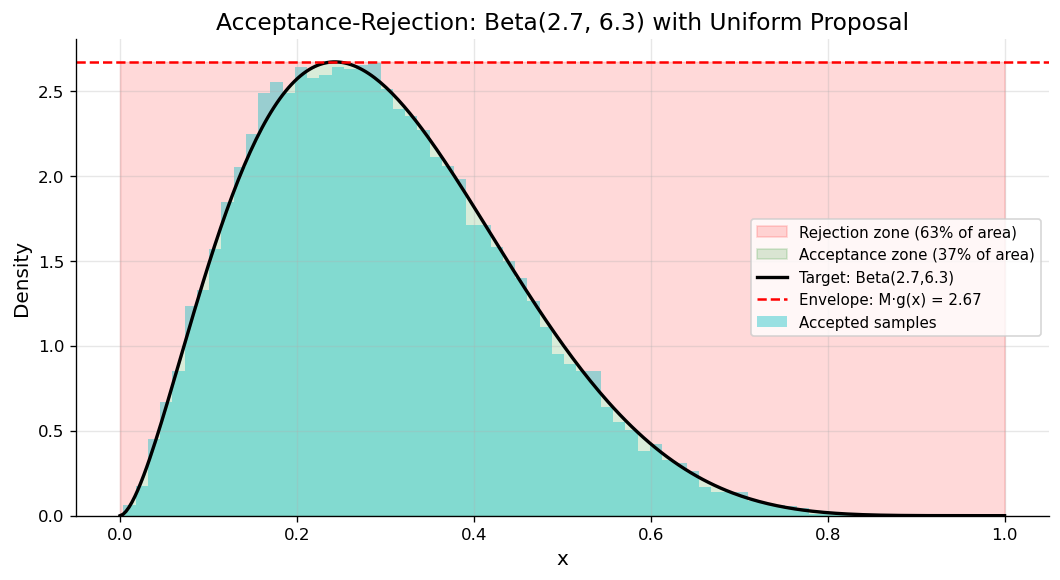

In [11]:
# Visualise: target, envelope, and accepted samples
fig, ax = plt.subplots(figsize=(9, 5))
x = np.linspace(0, 1, 300)

ax.fill_between(
    x,
    target.pdf(x),
    M_uniform,
    alpha=0.15,
    color="red",
    label=f"Rejection zone ({100 * (1 - 1 / M_uniform):.0f}% of area)",
)
ax.fill_between(
    x,
    0,
    target.pdf(x),
    alpha=0.15,
    color="green",
    label=f"Acceptance zone ({100 / M_uniform:.0f}% of area)",
)
ax.plot(x, target.pdf(x), "k-", lw=2, label=f"Target: Beta({a},{b})")
ax.axhline(
    M_uniform, color="red", ls="--", lw=1.5, label=f"Envelope: M·g(x) = {M_uniform:.2f}"
)
ax.hist(
    samples_ar,
    bins=60,
    density=True,
    alpha=0.4,
    color=str(C.CYAN),
    label="Accepted samples",
)

ax.set_xlabel("x")
ax.set_ylabel("Density")
ax.set_title("Acceptance-Rejection: Beta(2.7, 6.3) with Uniform Proposal")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

### 3.5 Visualising acceptance and rejection

The animation below generates random points under the envelope $M \cdot g(x)$. Points that fall below $f(x)$ (the target PDF) are **accepted** (green); points between $f(x)$ and the envelope are **rejected** (red). The accepted points, projected onto the $x$-axis, form samples from $f$.

Manim Community v0.18.1

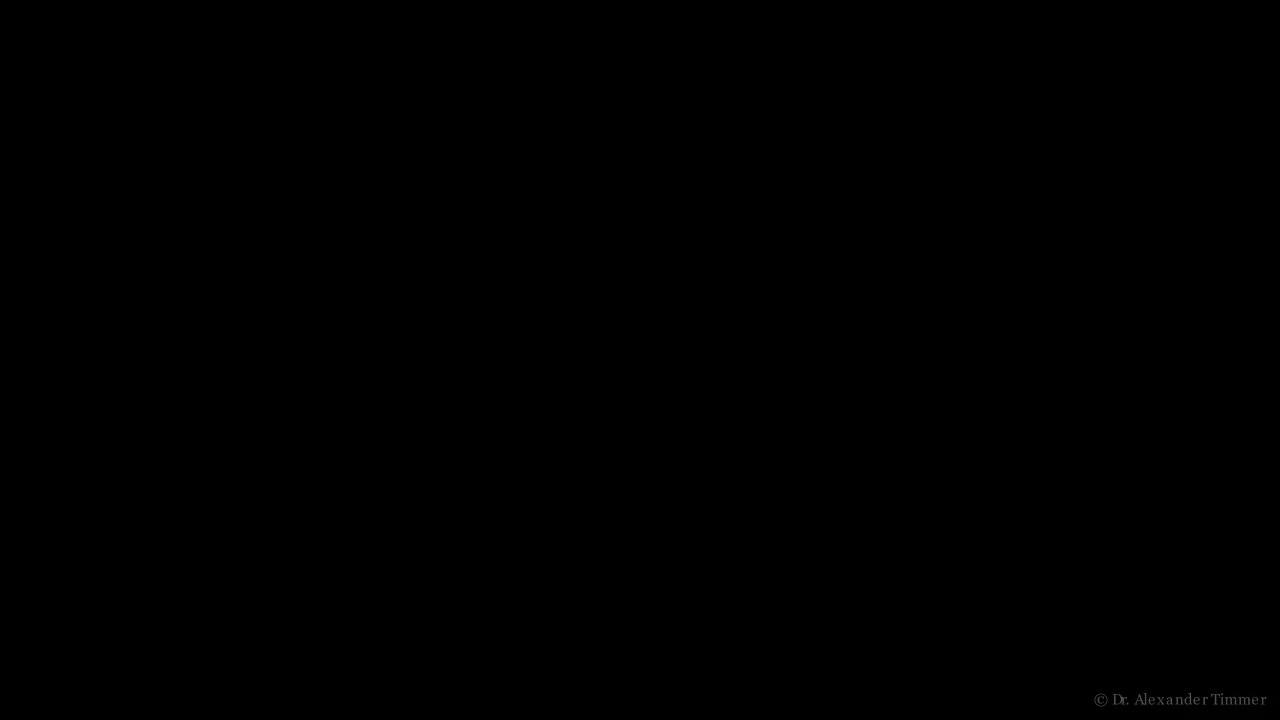

In [ ]:
%%manim -qm -v WARNING AcceptRejectDemo


class AcceptRejectDemo(Scene):
    """Animate acceptance-rejection sampling for Beta(2.7, 6.3)."""

    def construct(self):
        # Watermark — add first so it's present the entire animation
        watermark = Text(
            "© Dr. Alexander Timmer", font_size=12, color=GREY, fill_opacity=0.6
        )
        watermark.to_corner(DR, buff=0.15)
        self.add(watermark)

        a, b = 2.7, 6.3
        from scipy.stats import beta as beta_dist

        target = beta_dist(a, b)
        M = target.pdf((a - 1) / (a + b - 2))

        title = Text("Accept-Reject Sampling: Beta(2.7, 6.3)", font_size=26).to_edge(UP)
        self.play(Write(title), run_time=0.5)

        axes = Axes(
            x_range=[0, 1, 0.2],
            y_range=[0, 3, 0.5],
            x_length=10,
            y_length=5,
            axis_config={"include_numbers": True, "font_size": 16},
        ).shift(DOWN * 0.3)
        self.play(Create(axes), run_time=0.5)

        # Draw target PDF
        pdf_curve = axes.plot(
            lambda x: target.pdf(x), x_range=[0.01, 0.99], color=C.GOLD, stroke_width=3
        )
        # Draw envelope
        envelope = DashedLine(
            axes.c2p(0, M), axes.c2p(1, M), color=C.SALMON, stroke_width=2
        )
        self.play(Create(pdf_curve), Create(envelope), run_time=0.6)

        # Generate and animate points
        np.random.seed(123)
        n_points = 40
        accepted = 0
        rejected = 0

        counter_text = (
            Text(f"Accepted: 0 / 0", font_size=20, color=WHITE)
            .to_corner(UR)
            .shift(DOWN * 0.5)
        )
        self.play(Write(counter_text), run_time=0.3)

        for i in range(n_points):
            y = np.random.uniform(0.02, 0.98)
            h = np.random.uniform(0, M)
            is_accept = h <= target.pdf(y)

            dot = Dot(
                axes.c2p(y, h),
                radius=0.05,
                color=C.EMERALD if is_accept else C.SALMON,
                fill_opacity=0.8,
            )

            if is_accept:
                accepted += 1
            else:
                rejected += 1

            speed = 0.15 if i < 10 else 0.06
            self.play(FadeIn(dot), run_time=speed)

            new_counter = (
                Text(
                    f"Accepted: {accepted} / {accepted + rejected}",
                    font_size=20,
                    color=WHITE,
                )
                .to_corner(UR)
                .shift(DOWN * 0.5)
            )
            self.remove(counter_text)
            self.add(new_counter)
            counter_text = new_counter

        self.wait(1.5)

### 3.6 Improving efficiency with a better proposal

With the Uniform proposal, our acceptance rate was only about $\frac{1}{M} \approx 38\%$. We can do much better by choosing a proposal $g(x)$ that more closely matches the shape of $f(x)$.

For a Beta(2.7, 6.3) target, a natural choice is a Beta(2, 5) proposal — it has a similar shape but is wider, so it can act as an envelope.

In [13]:
# Better proposal: Beta(2, 5) — closer shape to the target
proposal = stats.beta(2, 5)

# Find M: max of f(x)/g(x) over [0, 1]
x_grid = np.linspace(0.001, 0.999, 10_000)
ratio = target.pdf(x_grid) / proposal.pdf(x_grid)
M_beta = ratio.max() * 1.001  # tiny safety margin
print(f"Better proposal: M = {M_beta:.4f}")
print(f"Acceptance rate = 1/M = {1 / M_beta:.4f} = {100 / M_beta:.1f}%")
print(
    f"(vs {100 / M_uniform:.1f}% with Uniform proposal — {M_uniform / M_beta:.1f}× improvement)"
)

Better proposal: M = 1.1822
Acceptance rate = 1/M = 0.8459 = 84.6%
(vs 37.5% with Uniform proposal — 2.3× improvement)


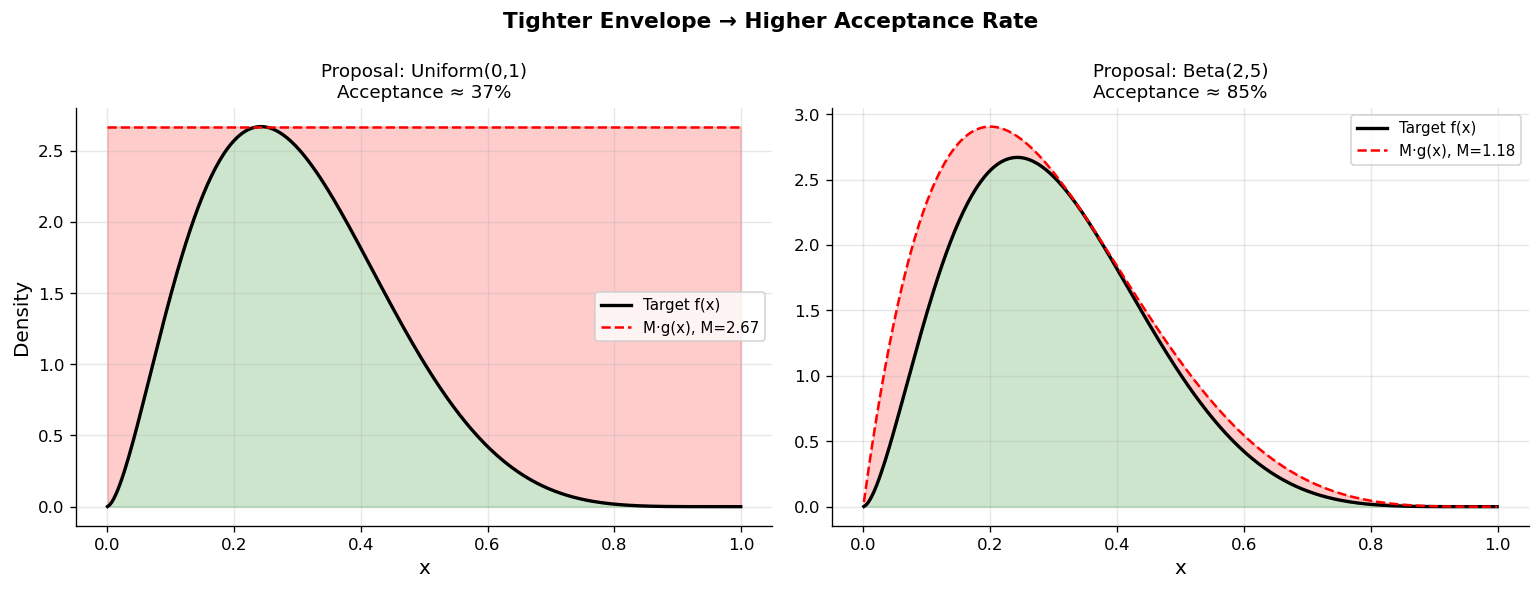

In [14]:
# Compare the two envelopes visually
fig, axes_plt = plt.subplots(1, 2, figsize=(13, 5))

x = np.linspace(0.001, 0.999, 300)

for ax, (M, g_pdf, g_name) in zip(
    axes_plt,
    [
        (M_uniform, np.ones_like(x), "Uniform(0,1)"),
        (M_beta, proposal.pdf(x), "Beta(2,5)"),
    ],
):
    envelope_vals = M * g_pdf
    ax.fill_between(x, target.pdf(x), envelope_vals, alpha=0.2, color="red")
    ax.fill_between(x, 0, target.pdf(x), alpha=0.2, color="green")
    ax.plot(x, target.pdf(x), "k-", lw=2, label="Target f(x)")
    ax.plot(x, envelope_vals, "r--", lw=1.5, label=f"M·g(x), M={M:.2f}")
    ax.set_title(f"Proposal: {g_name}\nAcceptance ≈ {100 / M:.0f}%", fontsize=11)
    ax.set_xlabel("x")
    ax.legend(fontsize=9)

axes_plt[0].set_ylabel("Density")
fig.suptitle(
    "Tighter Envelope → Higher Acceptance Rate", fontsize=13, fontweight="bold"
)
plt.tight_layout()
plt.show()

---

## 4. Importance Sampling

### 4.1 The problem

Sometimes we don't need *samples* from $f$ per se — we need to compute an **expectation**:

$$\mu = E_f[h(X)] = \int h(x) f(x)\, dx$$

If $f$ is hard to sample from, we can use a trick: sample from a *different* distribution $g$ (the **importance distribution**) and reweight.

### 4.2 The key identity

$$E_f[h(X)] = \int h(x) f(x)\, dx = \int h(x) \frac{f(x)}{g(x)} g(x)\, dx = E_g\left[h(X) \cdot \frac{f(X)}{g(X)}\right]$$

The ratio $w(x) = f(x) / g(x)$ is called the **importance weight**. The estimator becomes:

$$\hat{\mu}_n = \frac{1}{n} \sum_{i=1}^n h(X_i) \cdot w(X_i), \quad X_i \sim g$$

This is unbiased for any $g$ with $g(x) > 0$ wherever $f(x) > 0$. But the **variance** depends critically on how well $g$ matches $f \cdot |h|$.

### 4.3 Why the choice of $g$ matters

The variance of the importance sampling estimator is:

$$\text{Var}_g\left[h(X) \cdot w(X)\right] = E_g\left[\left(h(X) \cdot \frac{f(X)}{g(X)}\right)^2\right] - \mu^2$$

If $g$ is very different from $f$ in the regions where $h(x) \cdot f(x)$ is large, some importance weights $w(X_i)$ will be enormous, making the estimator highly variable. The ideal importance distribution is $g^*(x) \propto |h(x)| \cdot f(x)$, but this is usually impractical to sample from (if we could, we wouldn't need importance sampling!).

**Rule of thumb:** Choose $g$ with **heavier tails** than $f$ in the region of interest. It's better to over-sample the tails than to miss them.

### 4.4 Worked example: estimating a tail probability

Let $X \sim N(0, 1)$. We want to estimate $P(X > 4) = E[\mathbf{1}_{X > 4}]$.

This probability is extremely small ($\approx 3.17 \times 10^{-5}$). With naive Monte Carlo (sampling from $N(0,1)$ and counting how often $X > 4$), most samples contribute nothing — we need millions of draws for a decent estimate.

**Importance sampling idea:** Sample from $g = N(4, 1)$ (centred on the region of interest) and reweight.

In [15]:
# Importance sampling: estimate P(X > 4) for X ~ N(0,1)
true_prob = stats.norm.sf(4)  # survival function = P(X > 4)
print(f"True P(X > 4) = {true_prob:.6e}")

n_samples = 10_000

# Method 1: Naive Monte Carlo
naive_samples = rng.standard_normal(n_samples)
naive_estimate = np.mean(naive_samples > 4)
print(f"\nNaive MC ({n_samples:,} samples):   P̂ = {naive_estimate:.6e}")

# Method 2: Importance sampling with g = N(4, 1)
g_samples = rng.normal(loc=4, scale=1, size=n_samples)
h_values = (g_samples > 4).astype(float)  # h(x) = 1_{x > 4}
weights = stats.norm.pdf(g_samples) / stats.norm(loc=4, scale=1).pdf(g_samples)
is_estimate = np.mean(h_values * weights)
print(f"Importance ({n_samples:,} samples):   P̂ = {is_estimate:.6e}")

True P(X > 4) = 3.167124e-05

Naive MC (10,000 samples):   P̂ = 0.000000e+00
Importance (10,000 samples):   P̂ = 3.145508e-05


Let's see how the two estimators converge as we increase the number of samples. Importance sampling should converge much faster because it concentrates its samples in the region that matters.

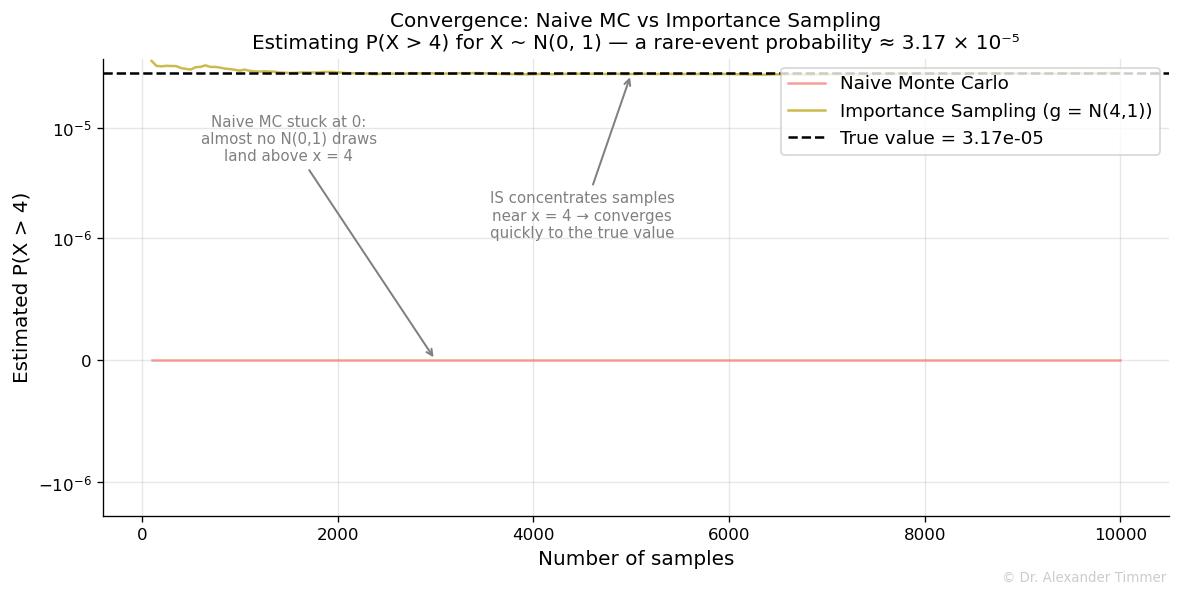

In [30]:
# Convergence comparison: naive vs importance sampling
n_values = np.arange(100, n_samples + 1, 50)

naive_running = np.cumsum(naive_samples > 4) / np.arange(1, n_samples + 1)
is_running = np.cumsum(h_values * weights) / np.arange(1, n_samples + 1)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(n_values, naive_running[n_values - 1], alpha=0.7, label="Naive Monte Carlo")
ax.plot(
    n_values,
    is_running[n_values - 1],
    alpha=0.7,
    label="Importance Sampling (g = N(4,1))",
)
ax.axhline(true_prob, color="k", ls="--", lw=1.5, label=f"True value = {true_prob:.2e}")

ax.set_xlabel("Number of samples")
ax.set_ylabel("Estimated P(X > 4)")
ax.set_title(
    "Convergence: Naive MC vs Importance Sampling\n"
    "Estimating P(X > 4) for X ~ N(0, 1) — a rare-event probability ≈ 3.17 × 10⁻⁵",
    fontsize=12,
)

# Annotate naive MC: explain why it flatlines at 0
ax.annotate(
    "Naive MC stuck at 0:\nalmost no N(0,1) draws\nland above x = 4",
    xy=(n_samples * 0.3, 0),
    xytext=(n_samples * 0.15, 5e-6),
    fontsize=9,
    ha="center",
    arrowprops=dict(arrowstyle="->", color="grey", lw=1.2),
    color="grey",
)

# Annotate importance sampling: highlight fast convergence
is_mid = is_running[n_samples // 2]
ax.annotate(
    "IS concentrates samples\nnear x = 4 → converges\nquickly to the true value",
    xy=(n_samples * 0.5, is_mid),
    xytext=(n_samples * 0.45, 1e-6),
    fontsize=9,
    ha="center",
    arrowprops=dict(arrowstyle="->", color="grey", lw=1.2),
    color="grey",
)

ax.legend(loc="upper right")
ax.set_yscale("symlog", linthresh=1e-6)

fig.text(
    0.98,
    0.01,
    "© Dr. Alexander Timmer",
    fontsize=8,
    color="grey",
    alpha=0.4,
    ha="right",
    va="bottom",
    transform=fig.transFigure,
)
plt.tight_layout()
plt.show()


### 4.5 Connection to Bayesian inference

Importance sampling is the foundation of several key algorithms in Bayesian computation:

- **Sequential Monte Carlo** (particle filters) use importance sampling to track a posterior distribution as data arrives sequentially.
- **PSIS-LOO** (Pareto-Smoothed Importance Sampling Leave-One-Out), used in ArviZ for model comparison (Module 08.03), is an importance sampling method.
- The transition from importance sampling to **MCMC** (Module 07) can be understood as moving from "reweight existing samples" to "generate new samples that are already from the target." 

---

## 5. Comparing the Three Methods

|                | Inverse Transform               | Accept-Reject                          | Importance Sampling                 |
|----------------|---------------------------------|----------------------------------------|-------------------------------------|
| **Requires**   | $F^{-1}$ in closed form         | Proposal $g$ with $f \leq Mg$          | Proposal $g$ with matching support  |
| **Output**     | Exact i.i.d. samples            | Exact i.i.d. samples                   | Weighted samples (for expectations) |
| **Efficiency** | 100% (one uniform → one sample) | $1/M$ acceptance rate                  | Depends on weight variance          |
| **Best for**   | Standard distributions          | Complex PDFs, bounded support          | Tail probabilities, rare events     |
| **Limitation** | Needs invertible CDF            | Efficiency degrades in high dimensions | High weight variance if $g$ is poor |

All three methods start from the same building block: uniform random numbers. They differ in how they transform those uniforms into samples from the target. In Module 07, we'll see how **Markov Chain Monte Carlo** extends these ideas to sample from distributions that are only known up to a normalising constant — exactly the situation in Bayesian inference.

---

## Key Takeaways

1. **The inverse transform method** converts $U \sim \text{Uniform}(0,1)$ into $X \sim F$ via $X = F^{-1}(U)$. It is exact and efficient, but requires the CDF inverse in closed form.

2. **Acceptance-rejection sampling** works with the PDF directly: propose from an easy distribution, accept with probability proportional to the target-to-envelope ratio. The tighter the envelope, the higher the efficiency.

3. **Importance sampling** reweights samples from an easy distribution to estimate expectations under a hard-to-sample distribution. The choice of importance distribution critically affects variance.

4. **Efficiency matters.** A bad proposal in accept-reject (large $M$) or a bad importance distribution (high weight variance) can make these methods practically useless. This is the same challenge that motivates the sophisticated MCMC algorithms in Module 07.

5. **These are the foundations of computational statistics.** Every modern sampling algorithm — Metropolis-Hastings, Hamiltonian Monte Carlo, Sequential Monte Carlo — builds on the ideas in this notebook.

---

## Exercises

**Exercise 4.1 (Inverse transform for Cauchy).** The standard Cauchy distribution has CDF $F(x) = \frac{1}{2} + \frac{1}{\pi} \arctan(x)$. Derive $F^{-1}(u)$ and implement inverse transform sampling. Generate 10,000 samples, plot the histogram, and overlay the true PDF. Why is the histogram noisy even with so many samples? *(Hint: think about the variance of the Cauchy distribution.)*

**Exercise 4.2 (Accept-reject for semicircle).** The Wigner semicircle distribution on $[-1, 1]$ has PDF $f(x) = \frac{2}{\pi}\sqrt{1 - x^2}$. Implement acceptance-rejection using a Uniform(-1, 1) proposal. What is $M$? What is the theoretical acceptance rate? Verify empirically.

**Exercise 4.3 (Importance sampling for rare events).** Estimate $P(X > 5)$ where $X \sim N(0, 1)$ using (a) naive Monte Carlo with $n = 100{,}000$ and (b) importance sampling with $g = N(5, 1)$. Report the estimates and their standard errors. Which is more precise?

**Exercise 4.4 (Proposal design).** For the acceptance-rejection method applied to $\text{Beta}(5, 2)$: (a) compute the optimal $M$ using a Uniform proposal; (b) compute $M$ using a Beta(4, 2) proposal; (c) compare the acceptance rates. Why is the Beta proposal so much better?

In [31]:
cfg.save_gifs(clean=True)

  ✓ media/gifs/AcceptRejectDemo@2026-03-21@22-21-57.gif
  ✓ media/gifs/AcceptRejectDemo@2026-03-30@08-55-10.gif
  ✓ media/gifs/BetaPDFMorph@2026-03-21@21-14-24.gif
  ✓ media/gifs/BinomialPMFMorph@2026-03-19@15-56-51.gif
  ✓ media/gifs/CLTConvergence@2026-03-19@15-50-56.gif
  ✓ media/gifs/InverseTransformDemo@2026-03-21@22-20-38.gif
  ✓ media/gifs/InverseTransformDemo@2026-03-30@08-53-42.gif
  ✓ media/gifs/AcceptRejectDemo_ManimCE_v0.18.1.gif
  ✓ media/gifs/InverseTransformDemo_ManimCE_v0.18.1.gif
  Cleaned up local temp render files.


---

**Next:** [Module 03 — Descriptive Statistics](../03_descriptive_stats/01_summary_statistics.ipynb) — Summarising data: measures of centre, spread, and shape.